# OCR Reflow - Example Usage

This notebook demonstrates how to use the ocr-reflow package to process scanned documents and reflow text.

## Setup

First, let's import the necessary modules:

In [1]:
import sys
import cv2
import numpy as np
from matplotlib import pyplot as plt
from pathlib import Path

# Import the ocr_reflow package
from ocr_reflow import process_document, Letter

## Basic Usage

Process a document image and display the result:

In [2]:
# Path to your document image
image_path = "../images/dvurog_p007.png"  # Change this to your image path

# Check if file exists
if Path(image_path).exists():
    print(f"Processing: {image_path}")
else:
    print(f"File not found: {image_path}")
    print("Please update the image_path variable with a valid image file.")

Processing: ../images/dvurog_p007.png


In [3]:
# Process the document
result_image = process_document(image_path)

print(f"Result image shape: {result_image.shape}")
print(f"Result image dtype: {result_image.dtype}")

Detected background color (BGR): [228 228 228]
Detected 3 paragraphs
Paragraph starts at indices: [0, 725, 773]
Average first letter xmin: 254.21428571428572
Paragraph 0 starts at line 0 with indentation (xmin): 238
Paragraph 1 starts at line 12 with indentation (xmin): 262
Paragraph 2 starts at line 13 with indentation (xmin): 816
Average line width: 1143.0, Short line threshold: 800.0999999999999
Line 13 is short (width: 20), marking letter 773 as end of short line
Average character width (scaled): 54
Line start indices: [73, 139, 206, 273, 332, 384, 438, 528, 576, 632, 687, 725, 773]
Adding word space before letter 73 (new original line)
Adding word space before letter 139 (new original line)
Adding word space before letter 206 (new original line)
Adding word space before letter 273 (new original line)
Adding word space before letter 332 (new original line)
Adding word space before letter 384 (new original line)
Adding word space before letter 438 (new original line)
Adding word spa

## Display Results

Let's display the original and reflowed images side by side:

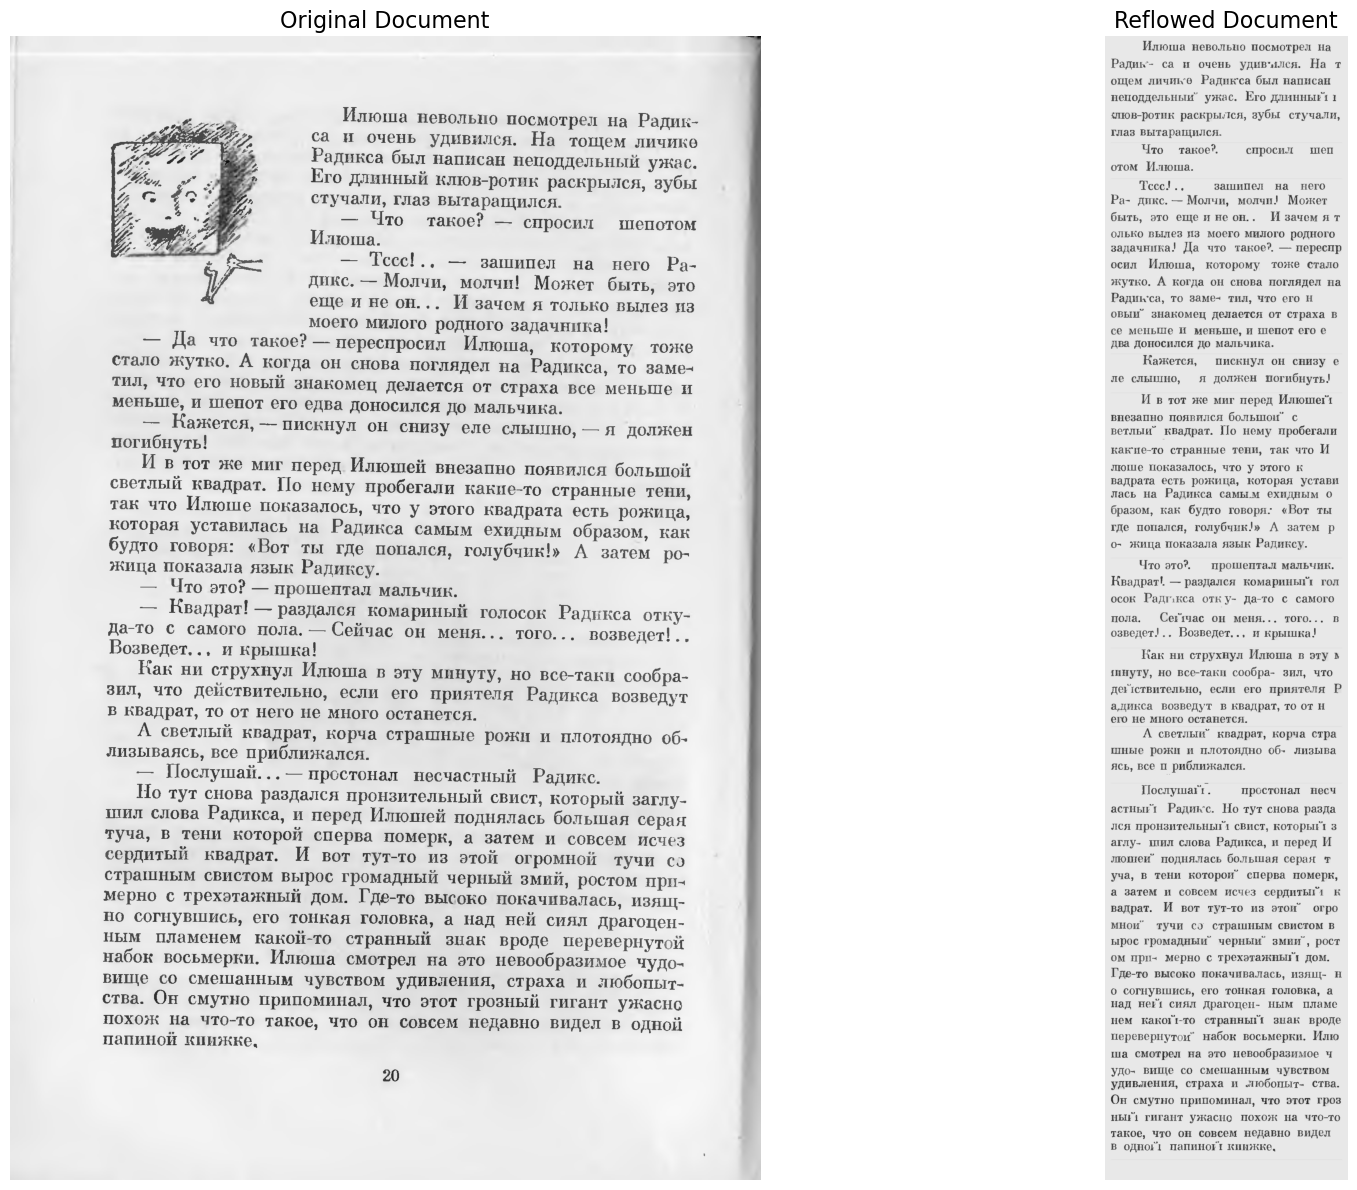

In [8]:
# Load original image
original_image = cv2.imread(image_path)
original_rgb = cv2.cvtColor(original_image, cv2.COLOR_BGR2RGB)
result_rgb = cv2.cvtColor(result_image, cv2.COLOR_BGR2RGB)

# Create figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(20, 12))

# Display original
axes[0].imshow(original_rgb)
axes[0].set_title('Original Document', fontsize=16)
axes[0].axis('off')

# Display reflowed
axes[1].imshow(result_rgb)
axes[1].set_title('Reflowed Document', fontsize=16)
axes[1].axis('off')

plt.tight_layout()
plt.show()

## Display Only the Reflowed Result

For a larger view of just the reflowed document:

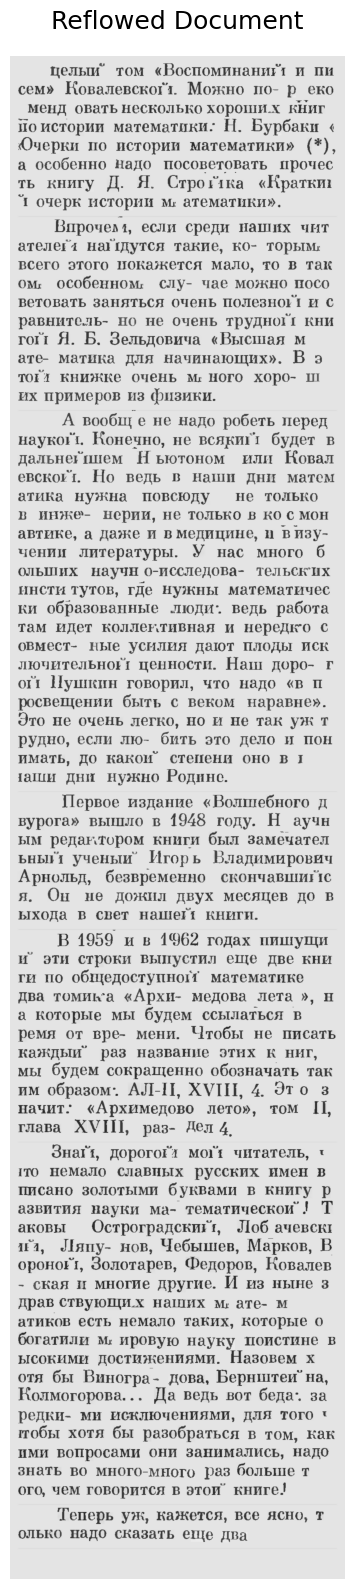

In [5]:
# Display just the reflowed result in a larger size
plt.figure(figsize=(12, 16))
plt.imshow(result_rgb)
plt.axis('off')
plt.title('Reflowed Document', fontsize=18, pad=20)
plt.tight_layout()
plt.show()

## Save the Result

Save the reflowed document to a file:

In [6]:
# Save the result
output_path = "../output_reflowed.png"
cv2.imwrite(output_path, result_image)
print(f"Saved reflowed document to: {output_path}")

Saved reflowed document to: ../output_reflowed.png


## Process Multiple Images

You can process multiple images in a batch:

In [ ]:
# List of images to process
image_files = [
    "../images/dvurog_p007.png",
    "../images/dvurog_p011.png",
    # Add more images as needed
]

# Process each image
for img_path in image_files:
    if Path(img_path).exists():
        print(f"Processing: {img_path}")
        result = process_document(img_path)
        
        # Save with _reflowed suffix
        output_path = img_path.replace('.png', '_reflowed.png')
        cv2.imwrite(output_path, result)
        print(f"  Saved to: {output_path}")
    else:
        print(f"File not found: {img_path}")

## Advanced: Access Individual Components

You can also use individual components of the package:

In [ ]:
from ocr_reflow import find_rects, margins
from doctr.models import detection_predictor
from doctr.io import DocumentFile

# Example: Use the detection model directly
model = detection_predictor(pretrained=True)
docs = DocumentFile.from_images([image_path])
result = model(docs)

print(f"Detected {len(result[0]['words'])} word regions")

## Summary

This notebook demonstrated:

1. Basic usage of `process_document()` function
2. Displaying original and reflowed images
3. Saving reflowed documents
4. Batch processing multiple images
5. Accessing individual package components

For more information, see the [README.md](../README.md) file.

In [4]:
from doclayout_yolo import YOLOv10
from huggingface_hub import hf_hub_download

In [5]:
filepath = hf_hub_download(repo_id="juliozhao/DocLayout-YOLO-DocStructBench", filename="doclayout_yolo_docstructbench_imgsz1024.pt")
model = YOLOv10(filepath)

In [7]:
image_path = "../images/dvurog_p007.png"
det_res = model.predict(
                image_path,   # Image to predict
                imgsz=1024,        # Prediction image size
                conf=0.2,          # Confidence threshold
                device="cuda:0"    # Device to use (e.g., 'cuda:0' or 'cpu')
            )


image 1/1 /home/sergey/code/python/segmentation/notebooks/../images/dvurog_p007.png: 1024x704 8 plain texts, 1 abandon, 111.0ms
Speed: 3.3ms preprocess, 111.0ms inference, 117.8ms postprocess per image at shape (1, 3, 1024, 704)


In [8]:
names = det_res[0].names
blocknames = [names[int(n)] for n in det_res[0].boxes.cls]
xyxy = [a.tolist() for a in det_res[0].boxes.xyxy]
res = [{"coords": y, "type": x} for x, y in zip(blocknames, xyxy)]

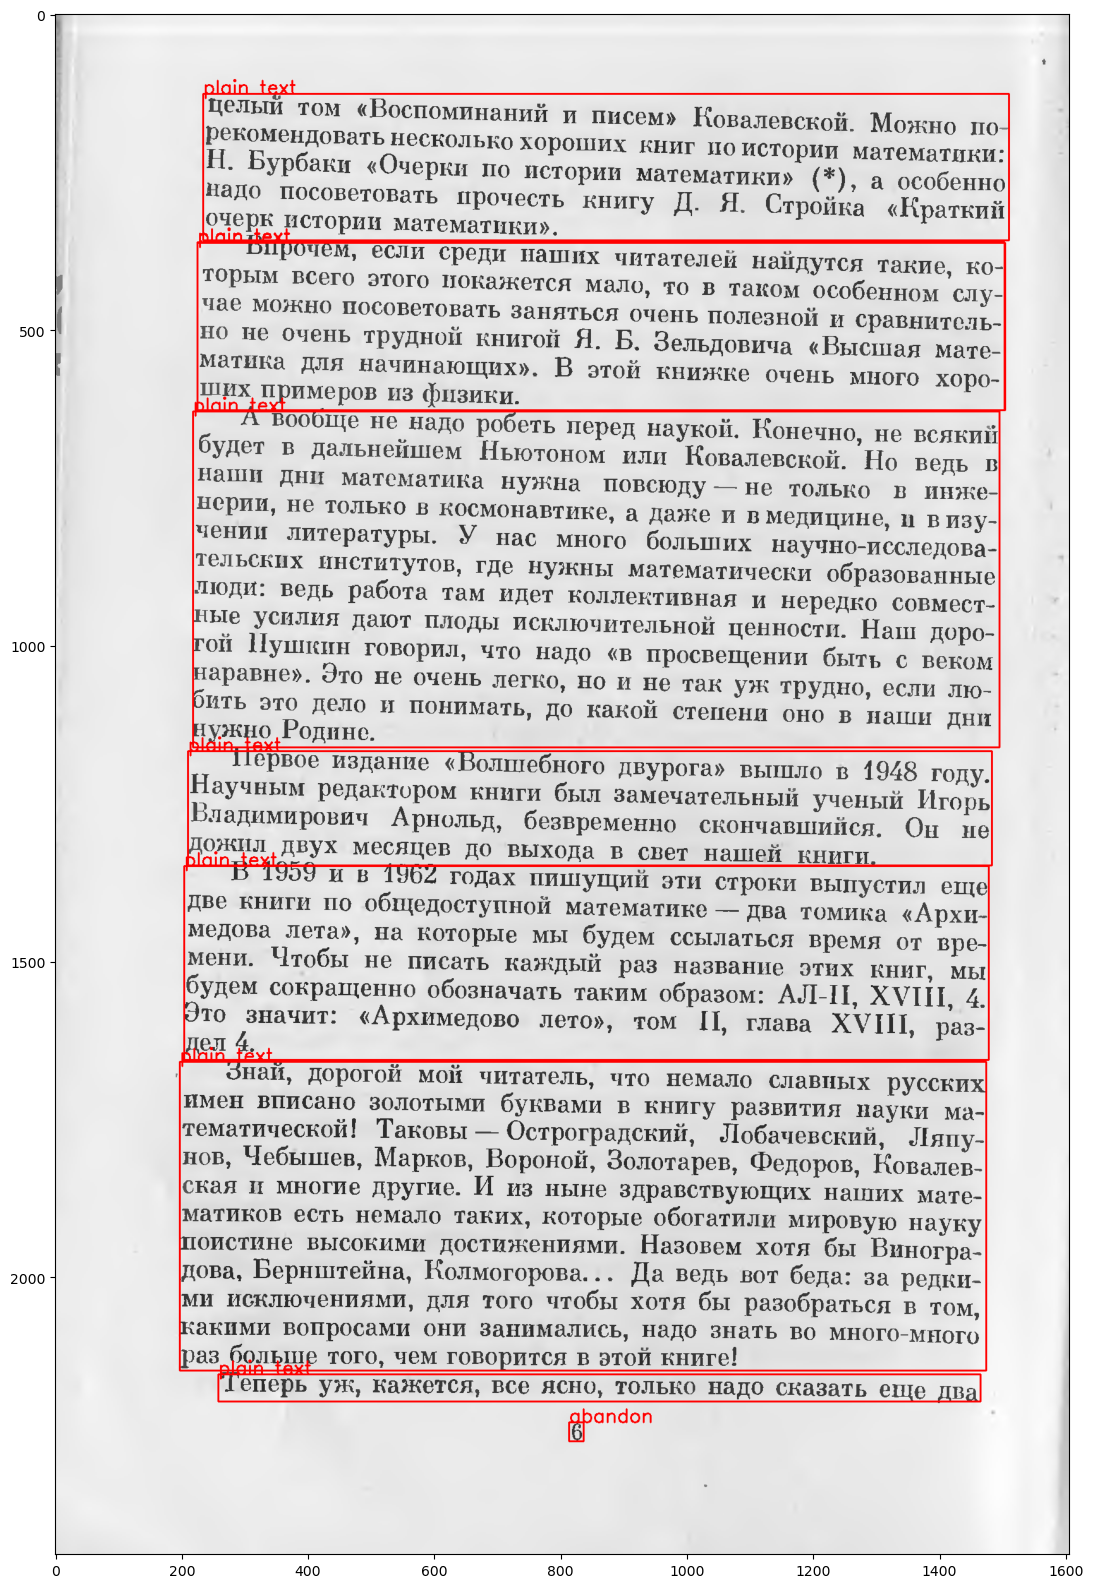

In [9]:
from matplotlib import pyplot as plt
plt.rcParams['figure.figsize'] = [20, 20]
import cv2
original_image = cv2.imread(image_path)
counter = 0
for xmin, ymin, xmax, ymax in xyxy:
    cv2.rectangle(original_image, (int(xmin), int(ymin)), (int(xmax), int(ymax)), (255, 0, 0), 2)
    cv2.putText(original_image, blocknames[counter], (int(xmin), int(ymin)), cv2.FONT_HERSHEY_SIMPLEX, 1, (255, 0, 0), 2)
    #cv2.imwrite("out" + str(counter) + ".png", original_image[int(ymin):int(ymax),int(xmin):int(xmax)])
    counter += 1

plt.imshow(original_image)   

In [70]:
names

{0: 'title',
 1: 'plain text',
 2: 'abandon',
 3: 'figure',
 4: 'figure_caption',
 5: 'table',
 6: 'table_caption',
 7: 'table_footnote',
 8: 'isolate_formula',
 9: 'formula_caption'}

In [7]:
from ocr_reflow.divide_conquer_4d import Point4D, divide_conquer_4d
rectangles = [(int(xmin),int(ymin),int(xmax),int(ymax))]
points4 = [
        Point4D(l, b, -r, -t, index=i)
        for i, (l, r, b, t) in enumerate(rectangles)
    ]

pairs4 = divide_conquer_4d(points4)
pairs4

set()

In [17]:
from shapely.geometry import box
from shapely.ops import unary_union
import networkx as nx

In [14]:
boxes = [box(xmin,ymin,xmax,ymax) for xmin, ymin, xmax, ymax in xyxy]
rect_list = boxes


# 2. Finding all pairwise intersections
intersections = []
int_inds = []
for i in range(len(rect_list)):
    for j in range(i + 1, len(rect_list)):
        if rect_list[i].intersects(rect_list[j]):
            intersections.append(rect_list[i].intersection(rect_list[j]))
            int_inds.append((i,j))

print(intersections)

[<POLYGON ((225.701 362.173, 225.701 627.188, 1502.735 627.188, 1502.735 362....>]


In [13]:
int_inds

[(14, 23), (21, 22)]

In [20]:
def find_intersecting_sets(boxes):
    G = nx.Graph()
    for i, b1 in enumerate(boxes):
        G.add_node(i)
        for j in range(i + 1, len(boxes)):
            if b1.intersects(boxes[j]):
                G.add_edge(i, j)
    # Only return sets with length >= 2
    return {frozenset(component) for component in nx.connected_components(G) if len(component) > 1}


In [24]:
def find_intersecting_bounding_boxes(boxes,names):
    G = nx.Graph()
    for i, b1 in enumerate(boxes):
        G.add_node(i)
        for j in range(i + 1, len(boxes)):
            if b1.intersects(boxes[j]):
                G.add_edge(i, j)
    bounding_boxes = []
    for component in nx.connected_components(G):
        subset = [boxes[i] for i in component]
        union = unary_union(subset)
        bounding_boxes.append(box(*union.bounds))
    return bounding_boxes

In [25]:
find_intersecting_bounding_boxes(rect_list)

[<POLYGON ((1339.399 1439.374, 1339.399 1661.189, 11.946 1661.189, 11.946 143...>,
 <POLYGON ((1338.63 981.156, 1338.63 1202.93, 13.278 1202.93, 13.278 981.156,...>,
 <POLYGON ((1340.704 100.225, 1340.704 284.215, 10.679 284.215, 10.679 100.22...>,
 <POLYGON ((1339.216 1665.972, 1339.216 1796.748, 13.355 1796.748, 13.355 166...>,
 <POLYGON ((1338.989 285.349, 1338.989 419.838, 12.129 419.838, 12.129 285.34...>,
 <POLYGON ((585.425 449.744, 585.425 761.11, 225.811 761.11, 225.811 449.744,...>,
 <POLYGON ((1123.986 449.636, 1123.986 764.216, 767.938 764.216, 767.938 449....>,
 <POLYGON ((903.288 2050.454, 903.288 2136.912, 436.713 2136.912, 436.713 205...>,
 <POLYGON ((908.178 1873.911, 908.178 1962.588, 440.884 1962.588, 440.884 187...>,
 <POLYGON ((1337.112 886.409, 1337.112 978.976, 12.824 978.976, 12.824 886.40...>,
 <POLYGON ((941.985 1220.685, 941.985 1275.734, 413.506 1275.734, 413.506 122...>,
 <POLYGON ((621.67 1304.03, 621.67 1346.428, 80.061 1346.428, 80.061 1304.03,...>,
 <PO

In [46]:
from shapely.geometry import box
from shapely.ops import unary_union
import networkx as nx
from collections import defaultdict

def find_typewise_intersecting_bounding_boxes_with_types(boxes, types):
    type_to_indices = defaultdict(list)
    for idx, t in enumerate(types):
        type_to_indices[t].append(idx)

    bounding_boxes_with_types = []
    for t, indices in type_to_indices.items():
        G = nx.Graph()
        for i in indices:
            G.add_node(i)
        for i_idx, i in enumerate(indices):
            for j in indices[i_idx + 1:]:
                if boxes[i].intersects(boxes[j]):
                    G.add_edge(i, j)
        for component in nx.connected_components(G):
            subset = [boxes[i] for i in component]
            union = unary_union(subset)
            bounding_boxes_with_types.append((box(*union.bounds), t))
    return bounding_boxes_with_types

In [11]:
t = find_typewise_intersecting_bounding_boxes_with_types(rect_list, blocknames)

NameError: name 'find_typewise_intersecting_bounding_boxes_with_types' is not defined

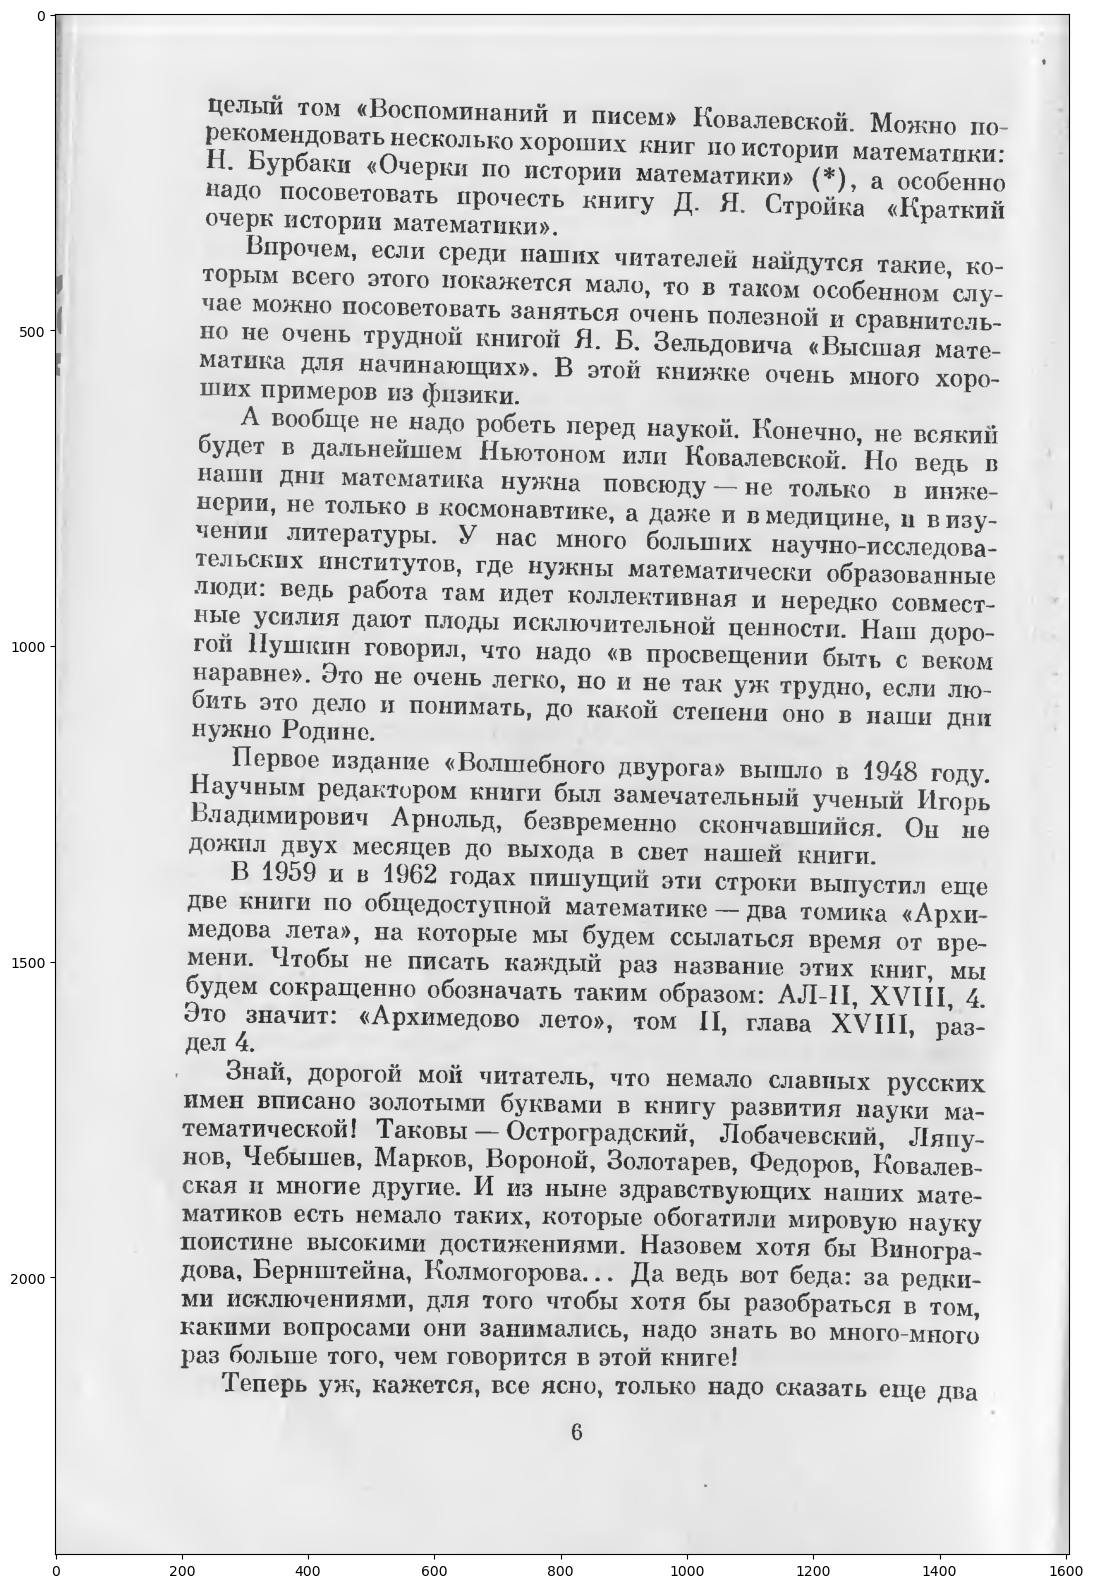

In [19]:
from matplotlib import pyplot as plt
plt.rcParams['figure.figsize'] = [20, 20]
import cv2
original_image = cv2.imread(image_path)

counter = 0

for r, tp in t:
    xmin, ymin, xmax,ymax = r.bounds
    #cv2.rectangle(original_image, (int(xmin), int(ymin)), (int(xmax), int(ymax)), (255, 0, 0), 2)
    #cv2.putText(original_image, tp, (int(xmin), int(ymin)), cv2.FONT_HERSHEY_SIMPLEX, 1, (255, 0, 0), 2)
    cv2.imwrite("out" + str(counter) + ".png", original_image[int(ymin):int(ymax),int(xmin):int(xmax)])
    counter += 1

plt.imshow(original_image)   

In [57]:
type(box(*t[0][0].bounds))

shapely.geometry.polygon.Polygon

In [12]:

from shapely.geometry import box
from shapely.ops import unary_union
import networkx as nx
from collections import defaultdict

def find_grouped_bounding_boxes(boxes, types):
    # Step 1: Index boxes by type
    type_to_indices = defaultdict(list)
    for idx, t in enumerate(types):
        type_to_indices[t].append(idx)

    result = []

    # Step 2: Handle "figure" and "figure caption"
    figures = type_to_indices.get("figure", [])
    captions = type_to_indices.get("figure caption", [])
    assigned_captions = set()
    figure_caption_pairs = []

    # Assign each caption to the nearest figure
    for cap_idx in captions:
        cap_box = boxes[cap_idx]
        min_dist = float("inf")
        nearest_fig = None
        for fig_idx in figures:
            fig_box = boxes[fig_idx]
            dist = cap_box.centroid.distance(fig_box.centroid)
            if dist < min_dist:
                min_dist = dist
                nearest_fig = fig_idx
        if nearest_fig is not None:
            figure_caption_pairs.append((nearest_fig, cap_idx))
            assigned_captions.add(cap_idx)

    used_figures = set()
    used_captions = set()
    for fig_idx, cap_idx in figure_caption_pairs:
        union = unary_union([boxes[fig_idx], boxes[cap_idx]])
        result.append((box(*union.bounds), "figure and caption"))
        used_figures.add(fig_idx)
        used_captions.add(cap_idx)

    # Add unpaired figures
    for fig_idx in figures:
        if fig_idx not in used_figures:
            result.append((boxes[fig_idx], "figure"))

    # Add unpaired captions
    for cap_idx in captions:
        if cap_idx not in used_captions:
            result.append((boxes[cap_idx], "figure caption"))

    # Step 3: Group "plaintext" boxes by intersection
    plaintext_indices = type_to_indices.get("plaintext", [])
    if plaintext_indices:
        G = nx.Graph()
        for i in plaintext_indices:
            G.add_node(i)
        for i_idx, i in enumerate(plaintext_indices):
            for j in plaintext_indices[i_idx + 1:]:
                if boxes[i].intersects(boxes[j]):
                    G.add_edge(i, j)
        for component in nx.connected_components(G):
            subset = [boxes[i] for i in component]
            union = unary_union(subset)
            result.append((box(*union.bounds), "plaintext"))

    # Step 4: Add all other types as individual boxes
    for t, indices in type_to_indices.items():
        if t in {"figure", "figure caption", "plaintext"}:
            continue
        for idx in indices:
            result.append((boxes[idx], t))

    return result


In [15]:
t = find_grouped_bounding_boxes(rect_list, blocknames)

In [16]:
t

[(<POLYGON ((1494.801 629.53, 1494.801 1161.576, 218.472 1161.576, 218.472 629...>,
  'plain text'),
 (<POLYGON ((1473.674 1659.484, 1473.674 2148.186, 197.645 2148.186, 197.645 1...>,
  'plain text'),
 (<POLYGON ((1477.738 1349.762, 1477.738 1656.513, 204.131 1656.513, 204.131 1...>,
  'plain text'),
 (<POLYGON ((1509.761 126.049, 1509.761 358.444, 234.657 358.444, 234.657 126....>,
  'plain text'),
 (<POLYGON ((1482.545 1167.322, 1482.545 1348.133, 210.196 1348.133, 210.196 1...>,
  'plain text'),
 (<POLYGON ((1503.637 362.173, 1503.637 627.949, 225.48 627.949, 225.48 362.17...>,
  'plain text'),
 (<POLYGON ((1464.5 2154.253, 1464.5 2197.616, 258.476 2197.616, 258.476 2154....>,
  'plain text'),
 (<POLYGON ((1502.735 361.434, 1502.735 627.188, 225.701 627.188, 225.701 361....>,
  'plain text'),
 (<POLYGON ((836.932 2230.089, 836.932 2260.38, 813.547 2260.38, 813.547 2230....>,
  'abandon')]

In [82]:

def find_grouped_bounding_boxes(boxes, types):
    from shapely.geometry import box
    from shapely.ops import unary_union
    import networkx as nx
    from collections import defaultdict

    type_to_indices = defaultdict(list)
    for idx, t in enumerate(types):
        type_to_indices[t].append(idx)

    result = []

    # Step 1: Pair each caption to the nearest unpaired figure
    figures = set(type_to_indices.get("figure", []))
    captions = set(type_to_indices.get("figure caption", []))
    used_figures = set()
    used_captions = set()

    for cap_idx in captions:
        cap_box = boxes[cap_idx]
        min_dist = float("inf")
        nearest_fig = None
        for fig_idx in figures - used_figures:
            fig_box = boxes[fig_idx]
            dist = cap_box.centroid.distance(fig_box.centroid)
            if dist < min_dist:
                min_dist = dist
                nearest_fig = fig_idx
        if nearest_fig is not None:
            union = unary_union([boxes[nearest_fig], boxes[cap_idx]])
            result.append((box(*union.bounds), "figure and caption"))
            used_figures.add(nearest_fig)
            used_captions.add(cap_idx)

    # Step 2: Add unpaired figures
    for fig_idx in figures - used_figures:
        result.append((boxes[fig_idx], "figure"))

    # Step 3: Add unpaired captions
    for cap_idx in captions - used_captions:
        result.append((boxes[cap_idx], "figure caption"))

    # Step 4: Group "plain text" boxes by intersection
    plaintext_indices = type_to_indices.get("plain text", [])
    if plaintext_indices:
        G = nx.Graph()
        for i in plaintext_indices:
            G.add_node(i)
        for i_idx, i in enumerate(plaintext_indices):
            for j in plaintext_indices[i_idx + 1:]:
                if boxes[i].intersects(boxes[j]):
                    G.add_edge(i, j)
        for component in nx.connected_components(G):
            subset = [boxes[i] for i in component]
            union = unary_union(subset)
            result.append((box(*union.bounds), "plain text"))

    # Step 5: Add all other types as individual boxes
    for t, indices in type_to_indices.items():
        if t in {"figure", "figure caption", "plain text"}:
            continue
        for idx in indices:
            result.append((boxes[idx], t))

    return result

In [92]:
find_grouped_bounding_boxes(rect_list, blocknames)


Figure indices: {5, 6}
Caption indices: {13, 15}
  Caption 13 to Figure 5: distance = 205.46596373040123
  Caption 13 to Figure 6: distance = 573.5889380477346
  -> Pairing caption 13 with figure 5
  Caption 15 to Figure 6: distance = 203.55156583240978
  -> Pairing caption 15 with figure 6

Formula indices: {8, 10, 12, 7}
Formula caption indices: {16, 18}
  Formula caption 16 to Formula 8: distance = 636.2635886764842
  Formula caption 16 to Formula 10: distance = 917.7552553953858
  Formula caption 16 to Formula 12: distance = 823.2545533382686
  Formula caption 16 to Formula 7: distance = 665.8377317252152
  -> Pairing formula caption 16 with formula 8
  Formula caption 18 to Formula 10: distance = 1052.164978881594
  Formula caption 18 to Formula 12: distance = 945.4022605573801
  Formula caption 18 to Formula 7: distance = 638.9826520298943
  -> Pairing formula caption 18 with formula 7


[(<POLYGON ((585.425 449.744, 585.425 830.439, 225.811 830.439, 225.811 449.74...>,
  'figure and caption'),
 (<POLYGON ((1123.986 449.636, 1123.986 830.782, 767.938 830.782, 767.938 449....>,
  'figure and caption'),
 (<POLYGON ((1339.139 1873.911, 1339.139 1962.588, 440.884 1962.588, 440.884 1...>,
  'isolate_formula and caption'),
 (<POLYGON ((1337.283 2050.454, 1337.283 2136.912, 436.713 2136.912, 436.713 2...>,
  'isolate_formula and caption'),
 (<POLYGON ((941.985 1220.685, 941.985 1275.734, 413.506 1275.734, 413.506 122...>,
  'isolate_formula'),
 (<POLYGON ((906.392 1360.863, 906.392 1410.478, 450.266 1410.478, 450.266 136...>,
  'isolate_formula'),
 (<POLYGON ((1339.399 1439.374, 1339.399 1661.189, 11.946 1661.189, 11.946 143...>,
  'plain text'),
 (<POLYGON ((1338.63 981.156, 1338.63 1202.93, 13.278 1202.93, 13.278 981.156,...>,
  'plain text'),
 (<POLYGON ((1340.704 100.225, 1340.704 284.215, 10.679 284.215, 10.679 100.22...>,
  'plain text'),
 (<POLYGON ((1339.216 1665.972,

In [84]:
def find_grouped_bounding_boxes(boxes, types):
    from shapely.geometry import box
    from shapely.ops import unary_union
    import networkx as nx
    from collections import defaultdict

    type_to_indices = defaultdict(list)
    for idx, t in enumerate(types):
        type_to_indices[t].append(idx)

    result = []

    # Step 1: Pair each caption to the nearest unpaired figure
    figures = set(type_to_indices.get("figure", []))
    captions = set(type_to_indices.get("figure caption", []))
    used_figures = set()
    used_captions = set()

    for cap_idx in captions:
        cap_box = boxes[cap_idx]
        min_dist = float("inf")
        nearest_fig = None
        for fig_idx in figures - used_figures:
            fig_box = boxes[fig_idx]
            dist = cap_box.centroid.distance(fig_box.centroid)
            if dist < min_dist:
                min_dist = dist
                nearest_fig = fig_idx
        if nearest_fig is not None:
            union = unary_union([boxes[nearest_fig], boxes[cap_idx]])
            result.append((box(*union.bounds), "figure and caption"))
            used_figures.add(nearest_fig)
            used_captions.add(cap_idx)

    # Step 2: Add unpaired figures
    for fig_idx in figures - used_figures:
        result.append((boxes[fig_idx], "figure"))

    # Step 3: Add unpaired captions
    for cap_idx in captions - used_captions:
        result.append((boxes[cap_idx], "figure caption"))

    # Step 4: Group "plain text" boxes by intersection
    plaintext_indices = type_to_indices.get("plain text", [])
    if plaintext_indices:
        G = nx.Graph()
        for i in plaintext_indices:
            G.add_node(i)
        for i_idx, i in enumerate(plaintext_indices):
            for j in plaintext_indices[i_idx + 1:]:
                if boxes[i].intersects(boxes[j]):
                    G.add_edge(i, j)
        for component in nx.connected_components(G):
            subset = [boxes[i] for i in component]
            union = unary_union(subset)
            result.append((box(*union.bounds), "plain text"))

    # Step 5: Add all other types as individual boxes
    for t, indices in type_to_indices.items():
        if t in {"figure", "figure caption", "plain text"}:
            continue
        for idx in indices:
            result.append((boxes[idx], t))

    return result

In [88]:
[str(r) for r in rect_list]

['POLYGON ((1339.399169921875 1439.374267578125, 1339.399169921875 1661.189453125, 11.946115493774414 1661.189453125, 11.946115493774414 1439.374267578125, 1339.399169921875 1439.374267578125))',
 'POLYGON ((1338.629638671875 981.1558837890625, 1338.629638671875 1202.9298095703125, 13.27794361114502 1202.9298095703125, 13.27794361114502 981.1558837890625, 1338.629638671875 981.1558837890625))',
 'POLYGON ((1340.7044677734375 100.22525024414062, 1340.7044677734375 284.215087890625, 10.679261207580566 284.215087890625, 10.679261207580566 100.22525024414062, 1340.7044677734375 100.22525024414062))',
 'POLYGON ((1339.2156982421875 1665.9715576171875, 1339.2156982421875 1796.74755859375, 13.355371475219727 1796.74755859375, 13.355371475219727 1665.9715576171875, 1339.2156982421875 1665.9715576171875))',
 'POLYGON ((1338.988525390625 285.3494873046875, 1338.988525390625 419.837890625, 12.128990173339844 419.837890625, 12.128990173339844 285.3494873046875, 1338.988525390625 285.3494873046875)

In [89]:
def find_grouped_bounding_boxes(boxes, types):
    # Step 1: Index boxes by type
    type_to_indices = defaultdict(list)
    for idx, t in enumerate(types):
        type_to_indices[t].append(idx)

    result = []

    # Step 2: Handle "figure" and "figure_caption"
    figures = set(type_to_indices.get("figure", []))
    captions = set(type_to_indices.get("figure_caption", []))

    print(f"\nFigure indices: {figures}")
    print(f"Caption indices: {captions}")

    used_figures = set()
    used_captions = set()

    # Pair each caption to the nearest unpaired figure
    for cap_idx in captions:
        cap_box = boxes[cap_idx]
        min_dist = float("inf")
        nearest_fig = None
        for fig_idx in figures - used_figures:
            fig_box = boxes[fig_idx]
            dist = cap_box.centroid.distance(fig_box.centroid)
            print(f"  Caption {cap_idx} to Figure {fig_idx}: distance = {dist}")
            if dist < min_dist:
                min_dist = dist
                nearest_fig = fig_idx
        if nearest_fig is not None:
            print(f"  -> Pairing caption {cap_idx} with figure {nearest_fig}")
            union = unary_union([boxes[nearest_fig], boxes[cap_idx]])
            result.append((box(*union.bounds), "figure and caption"))
            used_figures.add(nearest_fig)
            used_captions.add(cap_idx)

    # Add unpaired figures
    for fig_idx in figures - used_figures:
        result.append((boxes[fig_idx], "figure"))

    # Add unpaired captions
    for cap_idx in captions - used_captions:
        result.append((boxes[cap_idx], "figure_caption"))

    # Step 3: Group "plain text" boxes by intersection
    plaintext_indices = type_to_indices.get("plain text", [])
    if plaintext_indices:
        G = nx.Graph()
        for i in plaintext_indices:
            G.add_node(i)
        for i_idx, i in enumerate(plaintext_indices):
            for j in plaintext_indices[i_idx + 1:]:
                if boxes[i].intersects(boxes[j]):
                    G.add_edge(i, j)
        for component in nx.connected_components(G):
            subset = [boxes[i] for i in component]
            union = unary_union(subset)
            result.append((box(*union.bounds), "plain text"))

    # Step 4: Add all other types as individual boxes
    for t, indices in type_to_indices.items():
        if t in {"figure", "figure_caption", "plain text"}:
            continue
        for idx in indices:
            result.append((boxes[idx], t))

    return result


In [91]:
def find_grouped_bounding_boxes(boxes, types):
    # Step 1: Index boxes by type
    type_to_indices = defaultdict(list)
    for idx, t in enumerate(types):
        type_to_indices[t].append(idx)

    result = []

    # Step 2: Handle "figure" and "figure_caption"
    figures = set(type_to_indices.get("figure", []))
    captions = set(type_to_indices.get("figure_caption", []))

    print(f"\nFigure indices: {figures}")
    print(f"Caption indices: {captions}")

    used_figures = set()
    used_captions = set()

    # Pair each caption to the nearest unpaired figure
    for cap_idx in captions:
        cap_box = boxes[cap_idx]
        min_dist = float("inf")
        nearest_fig = None
        for fig_idx in figures - used_figures:
            fig_box = boxes[fig_idx]
            dist = cap_box.centroid.distance(fig_box.centroid)
            print(f"  Caption {cap_idx} to Figure {fig_idx}: distance = {dist}")
            if dist < min_dist:
                min_dist = dist
                nearest_fig = fig_idx
        if nearest_fig is not None:
            print(f"  -> Pairing caption {cap_idx} with figure {nearest_fig}")
            union = unary_union([boxes[nearest_fig], boxes[cap_idx]])
            result.append((box(*union.bounds), "figure and caption"))
            used_figures.add(nearest_fig)
            used_captions.add(cap_idx)

    # Add unpaired figures
    for fig_idx in figures - used_figures:
        result.append((boxes[fig_idx], "figure"))

    # Add unpaired captions
    for cap_idx in captions - used_captions:
        result.append((boxes[cap_idx], "figure_caption"))

    # Step 3: Handle "isolate_formula" and "formula_caption"
    formulas = set(type_to_indices.get("isolate_formula", []))
    formula_captions = set(type_to_indices.get("formula_caption", []))

    print(f"\nFormula indices: {formulas}")
    print(f"Formula caption indices: {formula_captions}")

    used_formulas = set()
    used_formula_captions = set()

    # Pair each formula caption to the nearest unpaired formula
    for cap_idx in formula_captions:
        cap_box = boxes[cap_idx]
        min_dist = float("inf")
        nearest_formula = None
        for formula_idx in formulas - used_formulas:
            formula_box = boxes[formula_idx]
            dist = cap_box.centroid.distance(formula_box.centroid)
            print(f"  Formula caption {cap_idx} to Formula {formula_idx}: distance = {dist}")
            if dist < min_dist:
                min_dist = dist
                nearest_formula = formula_idx
        if nearest_formula is not None:
            print(f"  -> Pairing formula caption {cap_idx} with formula {nearest_formula}")
            union = unary_union([boxes[nearest_formula], boxes[cap_idx]])
            result.append((box(*union.bounds), "isolate_formula and caption"))
            used_formulas.add(nearest_formula)
            used_formula_captions.add(cap_idx)

    # Add unpaired formulas
    for formula_idx in formulas - used_formulas:
        result.append((boxes[formula_idx], "isolate_formula"))

    # Add unpaired formula captions
    for cap_idx in formula_captions - used_formula_captions:
        result.append((boxes[cap_idx], "formula_caption"))

    # Step 4: Group "plain text" boxes by intersection
    plaintext_indices = type_to_indices.get("plain text", [])
    if plaintext_indices:
        G = nx.Graph()
        for i in plaintext_indices:
            G.add_node(i)
        for i_idx, i in enumerate(plaintext_indices):
            for j in plaintext_indices[i_idx + 1:]:
                if boxes[i].intersects(boxes[j]):
                    G.add_edge(i, j)
        for component in nx.connected_components(G):
            subset = [boxes[i] for i in component]
            union = unary_union(subset)
            result.append((box(*union.bounds), "plain text"))

    # Step 5: Add all other types as individual boxes
    for t, indices in type_to_indices.items():
        if t in {"figure", "figure_caption", "isolate_formula", "formula_caption", "plain text"}:
            continue
        for idx in indices:
            result.append((boxes[idx], t))

    return result